Sample Image Embedding and Visualization Code


In [68]:
from PIL import Image
import torch
import clip

# Load the CLIP model
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

# Corrected image paths
image_paths = [
                r"C:\Users\admin\Desktop\qdrant_database\.ipynb_checkpoints\image1.png",
                r"C:\Users\admin\Desktop\qdrant_database\.ipynb_checkpoints\image2.jpeg",
                r"C:\Users\admin\Desktop\qdrant_database\.ipynb_checkpoints\image3.jpeg"]

# Preprocess and load images
images = [preprocess(Image.open(image_path)).unsqueeze(0).to(device) for image_path in image_paths]

print("Images loaded successfully!")


Images loaded successfully!


In [69]:
# Concatenate all images into a single batch
image_input = torch.cat(images)

# Generate image embeddings
with torch.no_grad():
    image_embeddings = model.encode_image(image_input)

# Normalize the embeddings for better performance
image_embeddings /= image_embeddings.norm(dim=-1, keepdim=True)

print("Image embeddings generated successfully!")


Image embeddings generated successfully!


In [70]:
# Convert embeddings to list format
image_vectors = image_embeddings.cpu().numpy().tolist()


In [71]:
from qdrant_client import QdrantClient
from qdrant_client.models import PointStruct, VectorParams, Distance

# Connect to Qdrant
client = QdrantClient(host="localhost", port=6333)

# Create a collection (if not exists)
client.recreate_collection(
    collection_name="image_collection",
    vectors_config=VectorParams(size=512, distance=Distance.COSINE)
)

# Insert embeddings
points = [PointStruct(id=i, vector=vector, payload={"image_path": image_paths[i]}) for i, vector in enumerate(image_vectors)]
client.upsert(collection_name="image_collection", points=points)

print("Embeddings stored in Qdrant successfully!")


C:\Users\admin\AppData\Local\Temp\ipykernel_5228\1995135989.py:8: DeprecationWarning: `recreate_collection` method is deprecated and will be removed in the future. Use `collection_exists` to check collection existence and `create_collection` instead.
  client.recreate_collection(


Embeddings stored in Qdrant successfully!


In [72]:
# Query with the first image embedding
search_result = client.search(
    collection_name="image_collection",
    query_vector=image_vectors[0],
    limit=3
)

# Print search results
for result in search_result:
    print(f"Image Path: {result.payload['image_path']}, Score: {result.score}")


Image Path: C:\Users\admin\Desktop\qdrant_database\.ipynb_checkpoints\image1.png, Score: 1.0
Image Path: C:\Users\admin\Desktop\qdrant_database\.ipynb_checkpoints\image3.jpeg, Score: 0.56581235
Image Path: C:\Users\admin\Desktop\qdrant_database\.ipynb_checkpoints\image2.jpeg, Score: 0.5626068


C:\Users\admin\AppData\Local\Temp\ipykernel_5228\3990360383.py:2: DeprecationWarning: `search` method is deprecated and will be removed in the future. Use `query_points` instead.
  search_result = client.search(


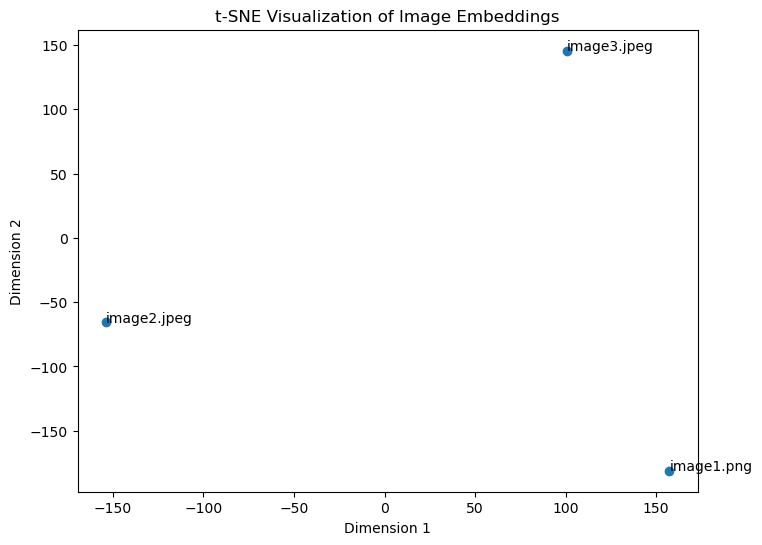

In [74]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Automatically set perplexity to (number of samples - 1)
perplexity_value = max(2, len(image_embeddings) - 1)

# Reduce to 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity_value)
reduced_embeddings = tsne.fit_transform(image_embeddings.cpu().numpy())

# Plot the reduced embeddings
plt.figure(figsize=(8, 6))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1])

# Label points with image names
for i, path in enumerate(image_paths):
    plt.annotate(path.split("\\")[-1], (reduced_embeddings[i, 0], reduced_embeddings[i, 1]))

plt.title("t-SNE Visualization of Image Embeddings")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()


Dimensionality Reduction and Visualization (for example, Image Embeddings)

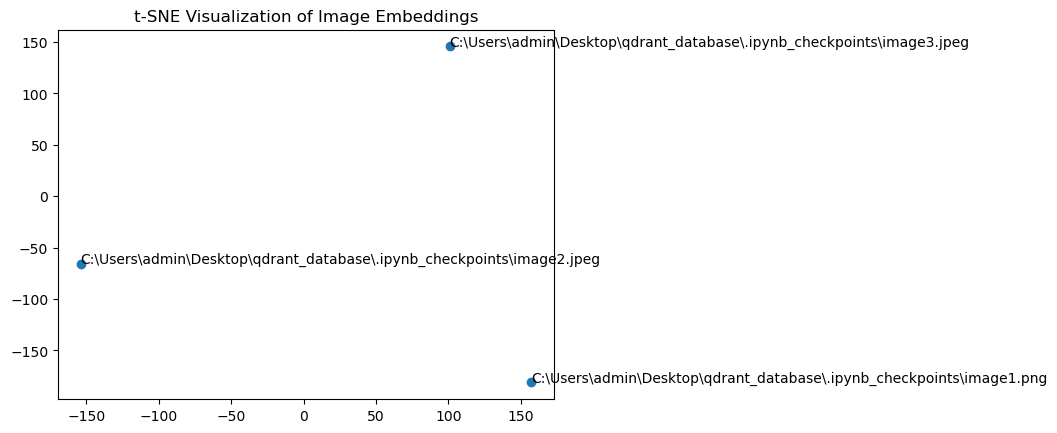

In [86]:
tsne = TSNE(n_components=2, random_state=42, perplexity=2)
reduced = tsne.fit_transform(image_embeddings)

plt.scatter(reduced[:, 0], reduced[:, 1])
for i, path in enumerate(image_paths):
    plt.annotate(path, (reduced[i, 0], reduced[i, 1]))
plt.title("t-SNE Visualization of Image Embeddings")
plt.show()
